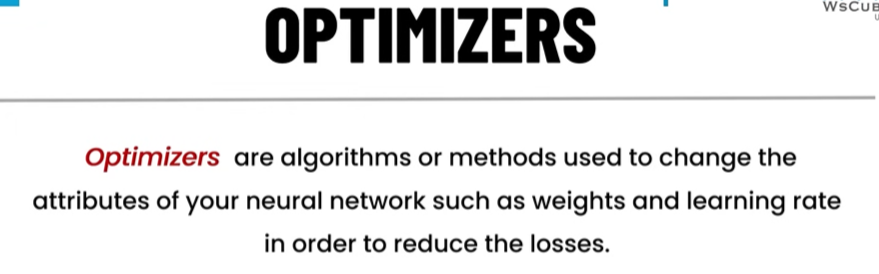

 TensorFlow deep learning project** me **Optimizers bhi implement** 

Hum ye optimizers implement karenge:

* SGD
* Momentum
* RMSProp
* Adam
* Adagrad
* Nadam

Same dataset pe train karenge.

---

# 1️⃣ Import Libraries

```python
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Nadam
```

---

# 2️⃣ Dataset Load

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("deep_learning_dataset.csv")

X = df[["cgpa","study_hours","projects","internships"]]
y = df["salary"]   # regression

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
```

---

# 3️⃣ MLP Model

```python
def create_model():

    model = Sequential([
        layers.Dense(32, activation='relu', input_shape=(4,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])

    return model
```

---

# 4️⃣ SGD Optimizer

```python
model_sgd = create_model()

optimizer_sgd = SGD(
    learning_rate=0.01
)

model_sgd.compile(
    optimizer=optimizer_sgd,
    loss='mse',
    metrics=['mae']
)

history_sgd = model_sgd.fit(
    X_train,y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)
```

---

# 5️⃣ SGD with Momentum

```python
model_momentum = create_model()

optimizer_momentum = SGD(
    learning_rate=0.01,
    momentum=0.9
)

model_momentum.compile(
    optimizer=optimizer_momentum,
    loss='mse',
    metrics=['mae']
)

history_momentum = model_momentum.fit(
    X_train,y_train,
    epochs=30,
    batch_size=32
)
```

---

# 6️⃣ RMSProp Optimizer

```python
model_rmsprop = create_model()

optimizer_rms = RMSprop(
    learning_rate=0.001
)

model_rmsprop.compile(
    optimizer=optimizer_rms,
    loss='mse',
    metrics=['mae']
)

history_rms = model_rmsprop.fit(
    X_train,y_train,
    epochs=30,
    batch_size=32
)
```

---

# 7️⃣ Adam Optimizer

Most used in deep learning.

```python
model_adam = create_model()

optimizer_adam = Adam(
    learning_rate=0.001
)

model_adam.compile(
    optimizer=optimizer_adam,
    loss='mse',
    metrics=['mae']
)

history_adam = model_adam.fit(
    X_train,y_train,
    epochs=30,
    batch_size=32
)
```

---

# 8️⃣ Adagrad Optimizer

```python
model_adagrad = create_model()

optimizer_adagrad = Adagrad(
    learning_rate=0.01
)

model_adagrad.compile(
    optimizer=optimizer_adagrad,
    loss='mse',
    metrics=['mae']
)

history_adagrad = model_adagrad.fit(
    X_train,y_train,
    epochs=30,
    batch_size=32
)
```

---

# 9️⃣ Nadam Optimizer

```python
model_nadam = create_model()

optimizer_nadam = Nadam(
    learning_rate=0.001
)

model_nadam.compile(
    optimizer=optimizer_nadam,
    loss='mse',
    metrics=['mae']
)

history_nadam = model_nadam.fit(
    X_train,y_train,
    epochs=30,
    batch_size=32
)
```

---

# 🔟 Compare All Optimizers

```python
print("SGD")
model_sgd.evaluate(X_test,y_test)

print("Momentum")
model_momentum.evaluate(X_test,y_test)

print("RMSProp")
model_rmsprop.evaluate(X_test,y_test)

print("Adam")
model_adam.evaluate(X_test,y_test)

print("Adagrad")
model_adagrad.evaluate(X_test,y_test)

print("Nadam")
model_nadam.evaluate(X_test,y_test)
```

---

# 1️⃣1️⃣ Advanced — Custom Optimizer (Expert Level)

Deep learning engineer level implementation.

Custom Gradient Descent:

```python
class CustomSGD(tf.keras.optimizers.Optimizer):

    def __init__(self, learning_rate=0.01, name="CustomSGD", **kwargs):
        super().__init__(name, **kwargs)
        self.learning_rate = learning_rate

    def apply_gradients(self, grads_and_vars):

        for grad, var in grads_and_vars:
            var.assign_sub(self.learning_rate * grad)
```

Use:

```python
optimizer = CustomSGD(learning_rate=0.01)

model = create_model()

model.compile(
    optimizer=optimizer,
    loss='mse'
)
```

---




### End to End Project of Customer Churn Prediction:--

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
dataset = pd.read_csv("Churn_Modelling.csv")

In [4]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [6]:
dataset.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
dataset.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
dataset.shape

(10000, 14)

In [9]:
dataset.size

140000

In [10]:
##  Divide data into dependent and independent

input_data = dataset.iloc[:,:-1]
output_data = dataset.iloc[:,-1]

In [11]:
from sklearn.preprocessing import StandardScaler

In [13]:
ss = StandardScaler()
ss.fit_transform(input_data)

ValueError: could not convert string to float: 'Hargrave'

In [14]:
# Select only columns that are integers or floats
numeric_data = input_data.select_dtypes(include=['int64', 'float64'])

ss = StandardScaler()
scaled_data = ss.fit_transform(numeric_data)

In [15]:
scaled_data

array([[-1.73187761, -0.78321342, -0.32622142, ...,  0.64609167,
         0.97024255,  0.02188649],
       [-1.7315312 , -0.60653412, -0.44003595, ..., -1.54776799,
         0.97024255,  0.21653375],
       [-1.73118479, -0.99588476, -1.53679418, ...,  0.64609167,
        -1.03067011,  0.2406869 ],
       ...,
       [ 1.73118479, -1.47928179,  0.60498839, ..., -1.54776799,
         0.97024255, -1.00864308],
       [ 1.7315312 , -0.11935577,  1.25683526, ...,  0.64609167,
        -1.03067011, -0.12523071],
       [ 1.73187761, -0.87055909,  1.46377078, ...,  0.64609167,
        -1.03067011, -1.07636976]], shape=(10000, 10))

In [18]:
input_data = pd.DataFrame(scaled_data = ss.fit_transform(numeric_data),columns=input_data.columns)

TypeError: DataFrame.__init__() got an unexpected keyword argument 'scaled_data'

In [17]:
input_data = pd.DataFrame(data=ss.fit_transform(numeric_data), columns=numeric_data.columns)

In [19]:
input_data

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,-1.731878,-0.783213,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-1.731531,-0.606534,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.731185,-0.995885,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687
3,-1.730838,0.144767,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918
4,-1.730492,0.652659,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276
...,...,...,...,...,...,...,...,...,...,...
9995,1.730492,-1.177652,1.246488,0.007457,-0.004426,-1.225848,0.807737,0.646092,-1.030670,-0.066419
9996,1.730838,-1.682806,-1.391939,-0.373958,1.724464,-0.306379,-0.911583,0.646092,0.970243,0.027988
9997,1.731185,-1.479282,0.604988,-0.278604,0.687130,-1.225848,-0.911583,-1.547768,0.970243,-1.008643
9998,1.731531,-0.119356,1.256835,0.293517,-0.695982,-0.022608,0.807737,0.646092,-1.030670,-0.125231


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(input_data,output_data,test_size=0.2,random_state=42)

In [29]:
x_train.shape

(8000, 10)

### Now use of Tensorflow Keras  deep learning:-->

In [31]:
import tensorflow

from keras.layers import Dense
from keras.models import Sequential

In [32]:
ann = Sequential()
ann.add(Dense(6,input_dim = 8,activation="relu"))
ann.add(Dense(4,input_dim = 8,activation="relu"))
ann.add(Dense(2,input_dim = 8,activation="relu"))
ann.add(Dense(1,input_dim = 8,activation="sigmoid"))


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
ann.compile(optimizer='adam',loss="binary_crossentropy",metrics=["accuracy"])

In [34]:
ann.fit(x_train,y_train, batch_size=100,epochs=10)

Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_4' is incompatible with the layer: expected axis -1 of input shape to have value 8, but received input with shape (100, 10)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(100, 10), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [50]:
from keras.layers import Input

ann = Sequential()

# 1. The Input Layer: Tells the model you have 10 features
ann.add(Input(shape=(10,))) 

# 2. Hidden Layers: Notice we don't need input_dim here anymore!
ann.add(Dense(units=6, activation="relu"))
ann.add(Dense(units=4, activation="relu"))
ann.add(Dense(units=2, activation="relu"))

# 3. Output Layer: Single neuron for binary classification
ann.add(Dense(units=1, activation="sigmoid"))

# Compile and Fit
ann.compile(optimizer='adam', loss="binary_crossentropy", metrics=["accuracy"])
ann.fit(x_train, y_train, batch_size=100, epochs=50)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5346 - loss: 0.7129 
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7694 - loss: 0.6513 
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7920 - loss: 0.5596 
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7945 - loss: 0.4899 
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7945 - loss: 0.4795 
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7945 - loss: 0.4707 
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7945 - loss: 0.4614 
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7945 - loss: 0.4512 
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7945 - loss: 0.4427 
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7945 - loss: 0.4360 
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7945 - loss: 0.4309  
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [51]:
prd = ann.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


In [52]:
prd_data = []
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)
    print(i[0])

0.038422495
0.04951409
0.10651351
0.12060856
0.061987095
0.016518258
0.19503865
0.062466778
0.39383015
0.300182
0.675882
0.675882
0.59980106
0.34404323
0.027431246
0.12553887
0.14299442
0.2136187
0.0479501
0.0333931
0.19177258
0.011603629
0.11412755
0.24654439
0.04562277
0.37600192
0.12541021
0.048498552
0.0064812433
0.16074036
0.06551391
0.027279658
0.19076867
0.029658122
0.18303767
0.675882
0.22482227
0.017177835
0.2318298
0.014708401
0.27225238
0.5645727
0.019067254
0.11321908
0.38121554
0.067343
0.07281818
0.25749412
0.2242117
0.088465706
0.09634891
0.29238826
0.52050936
0.23570548
0.675882
0.30295083
0.0123197045
0.05404612
0.2840094
0.062644556
0.06139885
0.008555774
0.19369556
0.1457582
0.08752438
0.20243388
0.0103743
0.30710664
0.3971726
0.12411469
0.07903581
0.26043233
0.5128905
0.15220694
0.0885778
0.12895633
0.004840195
0.079343565
0.14078052
0.1558369
0.014300889
0.34130192
0.23386468
0.25222352
0.3961326
0.6506587
0.21167785
0.43972555
0.085192546
0.058592062
0.037436094
0

In [53]:
from sklearn.metrics import accuracy_score

In [54]:
accuracy_score(y_test,prd_data)*100

85.39999999999999

In [55]:
accuracy_score(y_train,prd_data)*100

ValueError: Found input variables with inconsistent numbers of samples: [8000, 2000]